<a href="https://colab.research.google.com/github/ldaniel-hm/eml_k_bandit/blob/main/bandit_experiment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Estudio comparativo de algoritmos de Ascenso del Gradiente: Softmax y Gradiente de Preferencias

*Description:* El estudio compara el rendimiento de algoritmos de Ascenso del Gradiente (Softmax y Gradiente de Preferencias) en un problema de k-armed bandit.
Se generan gráficas diversas para cada algoritmo.


## Preparación del entorno


In [1]:
#@title Copiar el repositorio.

#!git clone github.com/aalonsopuig/k_brazos_AAPGAG.git
#!cd eml_k_bandit/

In [2]:
#@title Importamos todas las clases y funciones

import sys

# Añadir el directorio fuente al path de Python
sys.path.append('src')

# Verificar que se ha añadido correctamente
print(sys.path)

import numpy as np
from typing import List

from algorithms import Algorithm, Softmax, PreferenceGradient
from arms import ArmNormal, ArmBernoulli, ArmBinomial, ArmBeta, Bandit
from plotting import plot_average_rewards, plot_optimal_selections, plot_arm_statistics, plot_regret

['C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\python311.zip', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\DLLs', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\\Lib', 'C:\\Program Files\\WindowsApps\\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0', '', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\win32', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\\LocalCache\\local-packages\\Python311\\site-packages\\win32\\lib', 'C:\\Users\\aalon\\AppData\\Local\\Packages\\PythonSoftwareFoundation.Python.3.11_

## Experimento

Cada algoritmo se ejecuta en un problema de k-armed bandit durante un número de pasos de tiempo y ejecuciones determinado.
Se comparan los resultados de los algoritmos.

Este código ejecuta múltiples simulaciones de un problema de bandido k-brazos utilizando distintos algoritmos, calcula las recompensas promedio y el porcentaje de selecciones óptimas a lo largo de los pasos de tiempo

In [3]:

def run_experiment(bandit: Bandit, algorithms: List[Algorithm], steps: int, runs: int):
    """
    Ejecuta un experimento de multi-armed bandit para evaluar diferentes algoritmos.

    Parámetros:
    bandit: Instancia del problema Bandit, que contiene las probabilidades de recompensa de cada brazo.
    algorithms: Lista de algoritmos de selección de brazos a comparar.
    steps: Número de pasos (iteraciones) que se ejecutarán por cada corrida.
    runs: Número de veces que se repetirá el experimento para obtener promedios.

    Devuelve:
    rewards: Matriz con las recompensas promedio obtenidas por cada algoritmo en cada paso.
    optimal_selections: Matriz con el porcentaje de veces que cada algoritmo seleccionó el brazo óptimo.
    """
    
    optimal_arm = bandit.optimal_arm  # Identifica el brazo con la mejor recompensa esperada

    rewards = np.zeros((len(algorithms), steps))  # Inicializa matriz para acumular recompensas
    optimal_selections = np.zeros((len(algorithms), steps))  # Inicializa matriz para contar selecciones óptimas

    np.random.seed(seed)  # Fija la semilla para reproducibilidad

    for run in range(runs):  # Itera por cada corrida del experimento
        current_bandit = Bandit(arms=bandit.arms)  # Crea una nueva instancia del bandit para cada corrida

        for algo in algorithms:
            algo.reset()  # Reinicia el estado de cada algoritmo

        for step in range(steps):  # Itera por cada paso dentro de una corrida
            for idx, algo in enumerate(algorithms):  # Itera por cada algoritmo
                chosen_arm = algo.select_arm()  # El algoritmo selecciona un brazo
                reward = current_bandit.pull_arm(chosen_arm)  # Se obtiene la recompensa al tirar de ese brazo
                algo.update(chosen_arm, reward)  # El algoritmo actualiza su estrategia con el nuevo dato

                rewards[idx, step] += reward  # Acumula la recompensa obtenida en este paso para este algoritmo

                if chosen_arm == optimal_arm:
                    optimal_selections[idx, step] += 1  # Incrementa el contador si el brazo elegido fue el óptimo

    rewards /= runs  # Calcula el promedio de recompensas por cada paso y algoritmo
    optimal_selections = (optimal_selections / runs) * 100  # Convierte las selecciones óptimas a porcentaje

    return rewards, optimal_selections  # Devuelve las matrices de recompensas y selecciones óptimas

## Ejecución del experimento

Se realiza el experimento usando 10 brazos, cada uno de acuerdo a una distribución seleccionada (**Bernoulli** por defecto). Se realizan 500 ejecuciones de 1000 pasos cada una. Se contrastan 2 algoritmos UCB (UCB1 y UCB2)

In [4]:
# Parámetros del experimento
seed = 42
np.random.seed(seed)  # Fijar la semilla para reproducibilidad

k = 10  # Número de brazos
steps = 1000  # Número de pasos que se ejecutarán cada algoritmo
runs = 500  # Número de ejecuciones

Aunque todo el estudio está basado en bandidos de **distribución Bernoulli**, están implementadas también las **distribuciones Normal, Binomial, y Beta**. Para usarlas en este experimento tan solo hay que quitar la almohadilla (#) de la que se desee ejecutar a continuación.

In [5]:
# Creación del bandit
#bandit = Bandit(arms=ArmNormal.generate_arms(k)) # Generar un bandido con k brazos de distribución normal
bandit = Bandit(arms=ArmBernoulli.generate_arms(k))  # Crear un bandido con k brazos de distribución Bernoulli
#bandit = Bandit(arms=ArmBinomial.generate_arms(k))  # Crear un bandido con k brazos de distribución Binomial
#bandit = Bandit(arms=ArmBeta.generate_arms(k))  # Crear un bandido con k brazos de distribución Beta
print(bandit)

Bandit with 10 arms: ArmBernoulli(p=0.4), ArmBernoulli(p=0.86), ArmBernoulli(p=0.22), ArmBernoulli(p=0.69), ArmBernoulli(p=0.58), ArmBernoulli(p=0.15), ArmBernoulli(p=0.79), ArmBernoulli(p=0.67), ArmBernoulli(p=0.12), ArmBernoulli(p=0.88)


In [6]:

optimal_arm = bandit.optimal_arm
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

# Definimos los algoritmos a comparar: Softmax y Gradiente de Preferencias.
# Ambos métodos pertenecen a la categoría de "Ascenso del Gradiente", utilizando diferentes estrategias 
# para asignar probabilidades a las acciones basadas en la información obtenida hasta el momento.
#
# Elección de parámetros:
# - τ (tau) en Softmax = 0.1: Este parámetro controla el equilibrio entre exploración y explotación.
#   Valores pequeños (cercanos a 0) hacen que el algoritmo se vuelva más codicioso (greedy), favoreciendo
#   la selección del brazo con mejor recompensa estimada. Valores grandes distribuyen la probabilidad
#   de selección más uniformemente, favoreciendo la exploración. Se usa 0.1 porque mantiene un equilibrio adecuado.
#
# - α (alpha) en Gradiente de Preferencias = 0.1: Este parámetro es la tasa de aprendizaje y determina 
#   qué tan rápido el algoritmo ajusta sus preferencias por cada acción en función de las recompensas obtenidas.
#   Valores más altos hacen que las preferencias cambien rápidamente (más sensible a nuevas recompensas),
#   mientras que valores más bajos suavizan el aprendizaje. Se ha elegido 0.1 como valor comúnmente utilizado
#   en la literatura para proporcionar un aprendizaje estable y evitar cambios bruscos en la política de selección.
algorithms = [Softmax(k=k, tau=0.1), PreferenceGradient(k=k, alpha=0.1)]

# Ejecutar el experimento y obtener las recompensas promedio y promedio de las selecciones óptimas
rewards, optimal_selections = run_experiment(bandit, algorithms, steps, runs)


Optimal arm: 10 with expected reward=0.88


## Visualización de los resultados

### Recompensa Promedio vs Pasos de Tiempo.
Muestra cómo evolucionan las recompensas promedio obtenidas por cada algoritmo a lo largo de los pasos de tiempo.

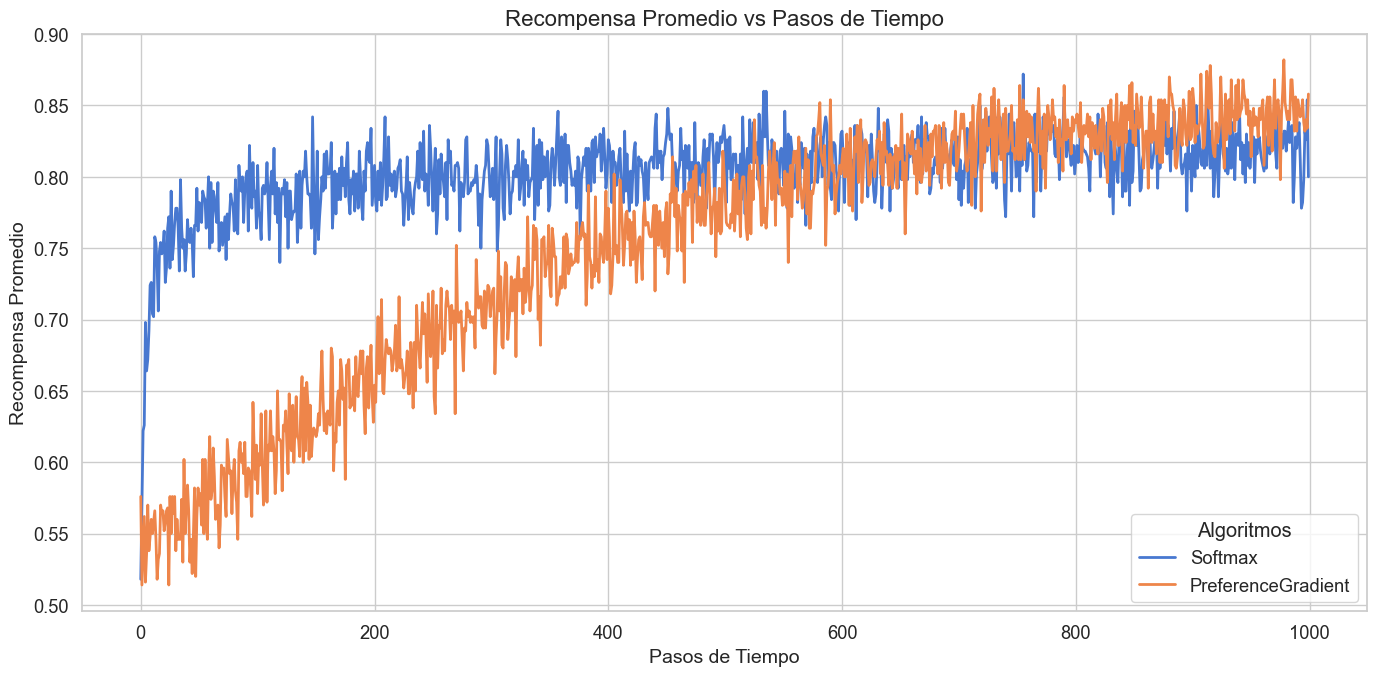

In [7]:
# Graficar los resultados
plot_average_rewards(steps, rewards, algorithms)  # Recompensa promedio a lo largo del tiempo

#### Análisis de las gráficas


**Observaciones:**
- **Softmax** (línea azul) comienza con una recompensa promedio más alta y se estabiliza rápidamente en torno a 0.80 - 0.83.
- **Gradiente de Preferencias** (línea naranja) tiene un aprendizaje más lento, pero con el tiempo mejora y alcanza un rendimiento similar, llegando a valores cercanos a Softmax después de 600 pasos.

**Explicación:**
- **Softmax** explora más al principio pero converge rápido a una estrategia estable.
- **Gradiente de Preferencias** ajusta las preferencias de manera progresiva, lo que le permite mejorar a largo plazo, aunque con más oscilaciones en la recompensa.

**Conclusión:**
Softmax ofrece un rendimiento inicial superior y más estable, mientras que el Gradiente de Preferencias tarda más en mejorar, pero termina alcanzando una recompensa similar. Esto sugiere que Softmax es más eficiente en problemas donde la exploración inicial es clave, mientras que Gradiente de Preferencias puede ser útil en entornos dinámicos donde la recompensa óptima puede cambiar.


### Porcentaje de Selección del Brazo Óptimo vs Pasos de Tiempo.
Esta métrica indica cuántas veces los algoritmos seleccionan el mejor brazo disponible.

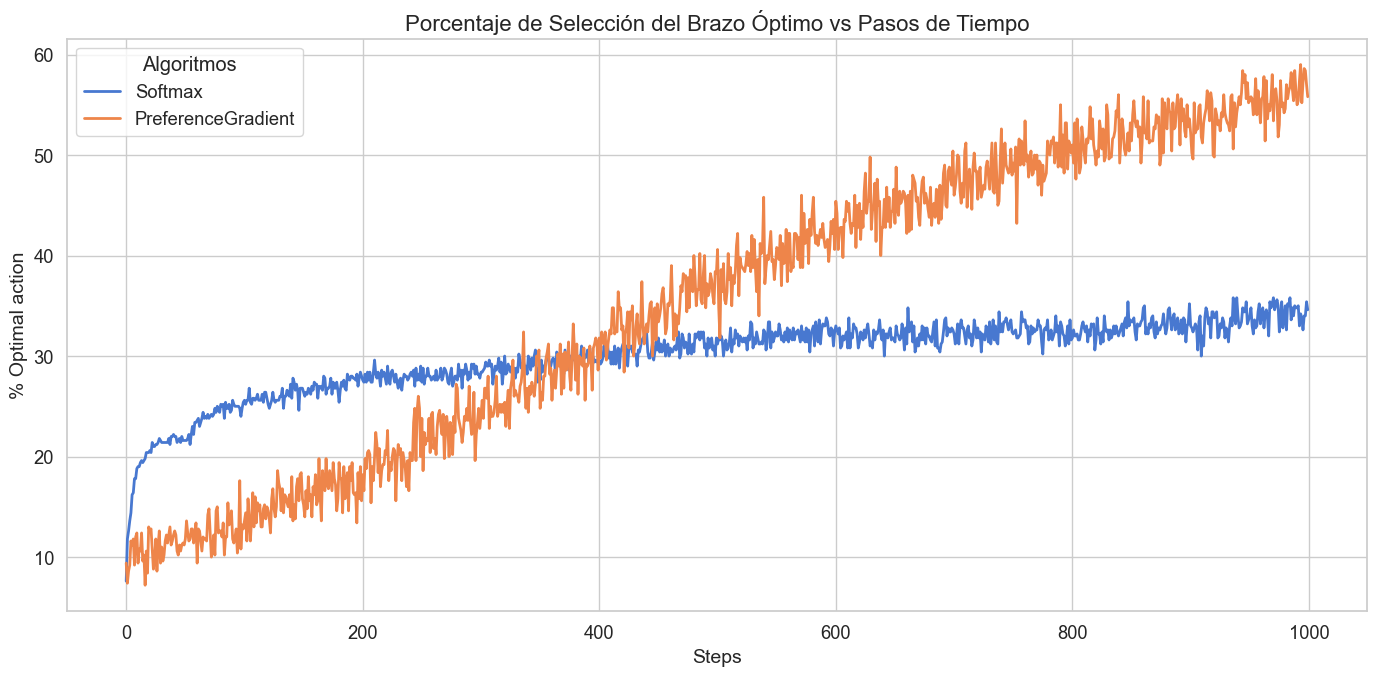

In [8]:
# Graficar la selección del brazo óptimo a lo largo del tiempo
plot_optimal_selections(steps, optimal_selections, algorithms)


#### Análisis de las gráficas

**Observaciones:**
- **Softmax** (línea azul) comienza con una tasa de selección del brazo óptimo más alta y se estabiliza rápidamente en torno al 30-35%.
- **Gradiente de Preferencias** (línea naranja) parte con una tasa menor, pero mejora progresivamente y supera a Softmax después de aproximadamente 400 pasos, alcanzando valores cercanos al 55% al final del experimento.

**Explicación:**
- **Softmax** explora de forma controlada, seleccionando acciones en función de probabilidades derivadas de la recompensa esperada, lo que lo lleva a estabilizarse temprano sin seguir mejorando significativamente.
- **Gradiente de Preferencias** ajusta sus selecciones de forma más dinámica, aprendiendo a favorecer el brazo óptimo con el tiempo, lo que le permite superar a Softmax en la etapa tardía del experimento.

**Conclusión:**
Softmax converge rápido a una estrategia estable pero sin seguir mejorando, mientras que el Gradiente de Preferencias muestra una mejora continua, lo que sugiere que es más adecuado en entornos donde el aprendizaje progresivo puede ofrecer ventajas a largo plazo.

### Estadísticas de cada brazo

Cada valor en el eje X representará un brazo. En el eje Y se representa el promedio de las ganancias de cada brazo. El gráfico mostrará un histograma para cada brazo donde se muestre el promedio de las ganancias obtenidas pero en el eje X, como etiqueta, se mostrará también el número de veces que fue seleccionado el brazo e indicar si es el brazo óptimo o no (estrella dorada).

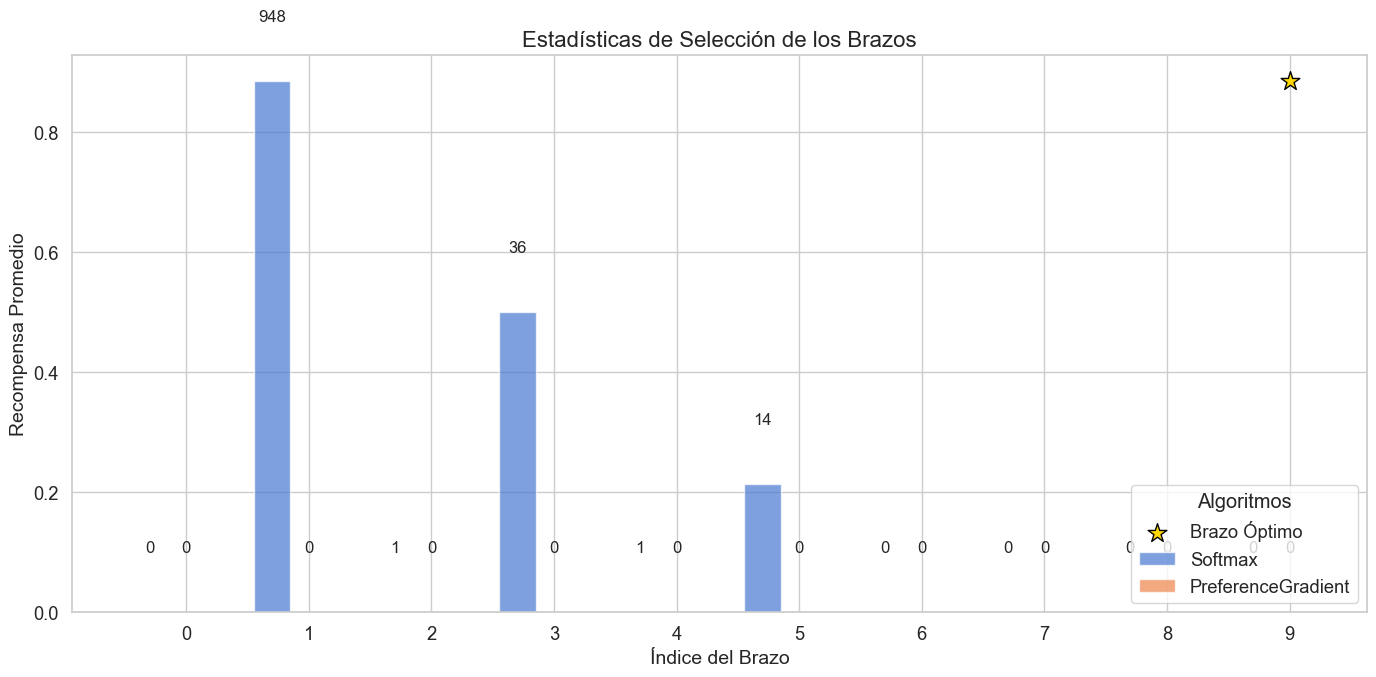

In [9]:
# Preparar los datos para la gráfica de estadísticas de brazos
arm_stats = []
for algo in algorithms:
    stats = {
        "means": algo.values,  # Recompensa promedio estimada por cada brazo
        "counts": algo.counts   # Número de veces que se seleccionó cada brazo
    }
    arm_stats.append(stats)

# Graficar estadísticas de los brazos, pasando el índice del brazo óptimo
plot_arm_statistics(arm_stats, algorithms, optimal_arm)


#### Análisis de las gráficas





TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO 






### Evolución del rechazo

Muestra la evolución del rechazo, de forma análoga a cómo se muestra la evolución de las recompensas.

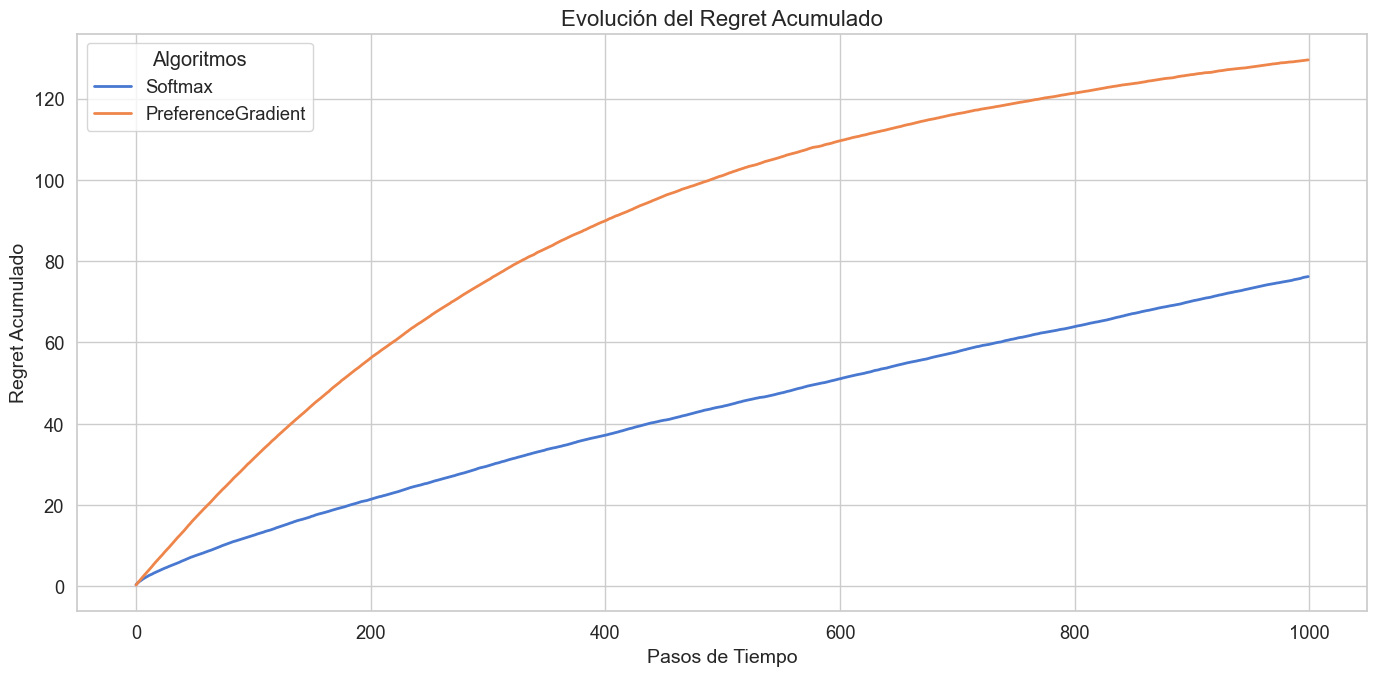

In [10]:
# Calcular el regret acumulado
optimal_reward = bandit.get_expected_value(optimal_arm)
regret_accumulated = np.cumsum(optimal_reward - rewards, axis=1)  # Regret acumulado por algoritmo

# Graficar la evolución del regret acumulado
plot_regret(steps, regret_accumulated, algorithms)

#### Análisis de las gráficas





TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO TODO 





# Temporal
Código para generar CSVs

In [11]:
algoritmo="ascenso_gradiente"
from utils.experiment_data_saver import ExperimentDataSaver
# Construir etiquetas de los algoritmos basadas en su parámetro específico (epsilon, tau, c, etc.)
algorithm_labels = [f"Softmax (tau={algo.tau})" if hasattr(algo, "tau") 
                    else f"UCB1 (c={algo.c})" if hasattr(algo, "c")
                    else f"{type(algo).__name__}" for algo in algorithms]

# Crear el objeto para gestionar los archivos del experimento
data_saver = ExperimentDataSaver(algoritmo, algorithm_labels)

# Guardar los archivos CSV en una sola línea cada uno
data_saver.save_data(rewards, "rewards")
data_saver.save_data(optimal_selections, "optimal_selections")
data_saver.save_data(regret_accumulated, "regret")
data_saver.save_data(arm_stats, "arm_statistics", is_arm_statistics=True)


Archivo guardado: data/ascenso_gradiente_rewards_sampled.csv
Archivo guardado: data/ascenso_gradiente_optimal_selections_sampled.csv
Archivo guardado: data/ascenso_gradiente_regret_sampled.csv
Archivo guardado: data/ascenso_gradiente_arm_statistics_sampled.csv
